# Import and Setup

In [14]:
import pandas as pd
merged_week_country = pd.read_csv(r"C:\Users\mkant\Documents\Intro to Python\CODE\LondonLab Data\merged_week_country.csv")#, #changing to without LOS
merged_week_country = merged_week_country[merged_week_country.COUNTRY == "Middle East - GCC"].drop(columns = 'Unnamed: 0')


In [12]:
merged_week_country.head()

,COUNTRY,TRANSACTIONS,ARRIVALS,LHR_arrivals,non_LHR_arrivals,premium_economy_and_above_arrivals,business_and_above_arrivals,first_arrivals,transactions_non_target,transactions_target,transactions_bronze_and_above,transactions_gold_and_above,transactions_black_and_above,transactions_platinum_and_above,transactions_elite_and_above
2,Middle East - GCC,901,1463,1330,133,482,263,29,120.0,781.0,704,564,429,140,47
7,Middle East - GCC,4314,7231,6682,549,1826,1015,138,607.0,3707.0,3357,2600,1906,706,248
12,Middle East - GCC,4453,8159,7528,631,1755,1285,187,523.0,3930.0,3543,2842,1969,708,246
17,Middle East - GCC,5051,7561,7203,358,2572,1542,197,685.0,4366.0,3888,2965,2080,954,257
22,Middle East - GCC,5226,9597,9026,571,4276,2022,265,755.0,4471.0,3913,3014,2226,885,265


In [15]:
display(list(merged_week_country.columns))

['DATE',
 'COUNTRY',
 'TRANSACTIONS',
 'ARRIVALS',
 'LHR_arrivals',
 'non_LHR_arrivals',
 'premium_economy_and_above_arrivals',
 'business_and_above_arrivals',
 'first_arrivals',
 'transactions_non_target',
 'transactions_target',
 'transactions_bronze_and_above',
 'transactions_gold_and_above',
 'transactions_black_and_above',
 'transactions_platinum_and_above',
 'transactions_elite_and_above']

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import IndexLocator

def plot_facet_lines(
    df,
    countries,
    date_col,
    y1_col,
    y2_col,
    y1_label=None,
    y2_label=None,
    col_wrap=3,
    height=5,
    aspect=1.5
):
    """
    Faceted line plots of two series over time, one on primary y-axis (blue),
    one on secondary y-axis (green), for specified countries, with a global legend.
    """
    y1_label = y1_label or y1_col
    y2_label = y2_label or y2_col

    filtered = df[df['COUNTRY'].isin(countries)]

    sns.set(style='whitegrid')
    g = sns.FacetGrid(
        filtered,
        col='COUNTRY',
        col_wrap=col_wrap,
        height=height,
        aspect=aspect,
        sharey=False
    )

    def _plot(data, **kwargs):
        ax = plt.gca()
        # primary series (blue)
        ax.plot(data[date_col], data[y1_col], color='tab:blue')
        ax.set_ylim(bottom=0)
        ax.set_ylabel(y1_label)
        # secondary series (green)
        ax2 = ax.twinx()
        ax2.plot(data[date_col], data[y2_col], color='tab:green')
        ax2.set_ylim(bottom=0)
        ax2.set_ylabel(y2_label)
        # x-labels
        ax.xaxis.set_major_locator(IndexLocator(8, 0))

        ax.tick_params(axis='x', rotation=30, labelsize=12)

    g.map_dataframe(_plot)

    # Create a global legend
    blue_line = plt.Line2D([], [], color='tab:blue', label=y1_label)
    green_line = plt.Line2D([], [], color='tab:green', label=y2_label)
    # place legend at top right INSIDE the figure
    g.fig.legend(
        handles=[blue_line, green_line],
        loc='upper right',
        bbox_to_anchor=(0.95, 0.95),
        frameon=False
    )

    plt.tight_layout()
    plt.show()


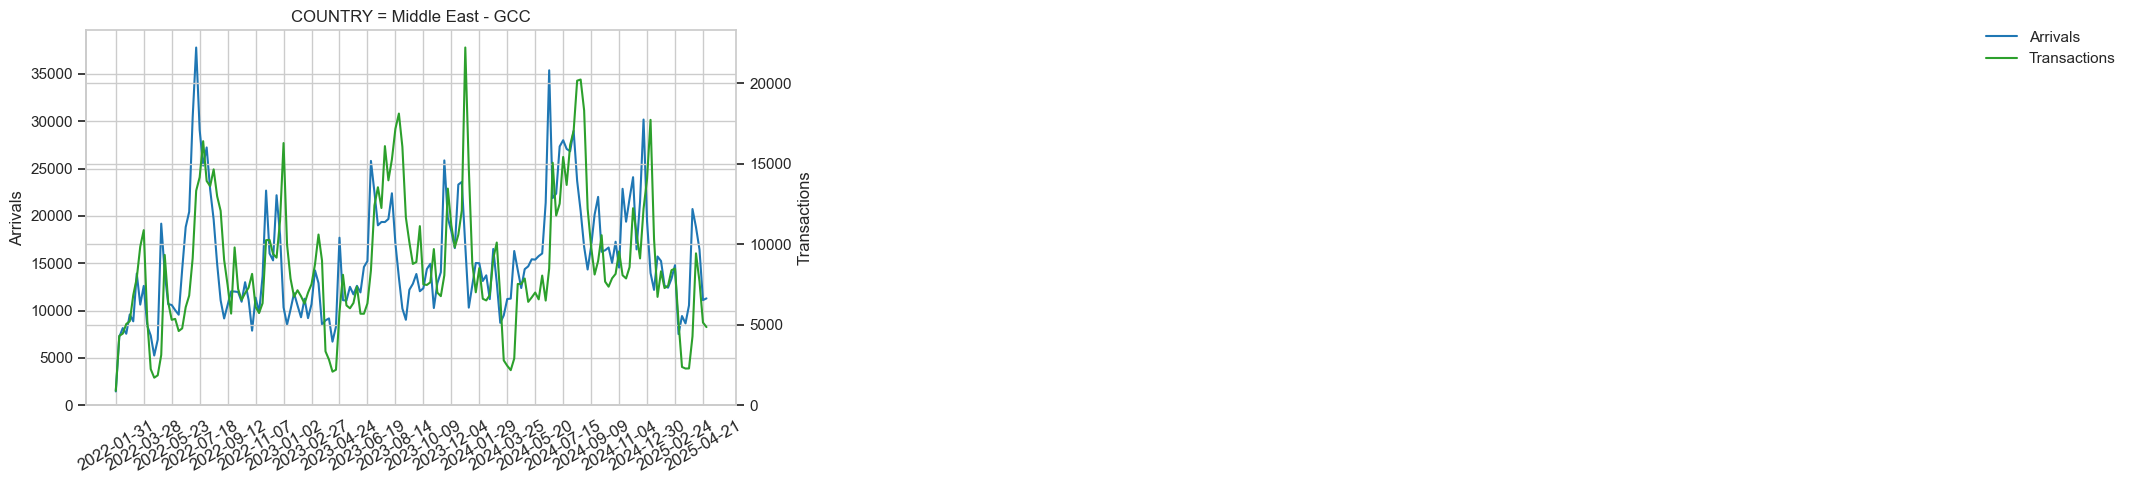

In [16]:
plot_facet_lines(
    merged_week_country,
    countries=['EU', 'Greater China', 'Middle East - GCC', 'North America', 'RO APAC'],
    date_col='DATE',
    y1_col='ARRIVALS',
    y2_col='TRANSACTIONS',
    y1_label='Arrivals',
    y2_label='Transactions',
    col_wrap=3
)

In [23]:
# 1. Filter to only Middle East - GCC
df_gcc = merged_week_country[merged_week_country['COUNTRY'] == 'Middle East - GCC'].copy()

# 2. Select only numeric columns (exclude DATE and COUNTRY)
numeric_cols = df_gcc.select_dtypes(include='number').columns

# 3. Compute the pairwise correlation matrix
corr_matrix = df_gcc[numeric_cols].corr()

# 4. (Optional) display or examine
display(corr_matrix)


,TRANSACTIONS,ARRIVALS,LHR_arrivals,non_LHR_arrivals,premium_economy_and_above_arrivals,business_and_above_arrivals,first_arrivals,transactions_non_target,transactions_target,transactions_bronze_and_above,transactions_gold_and_above,transactions_black_and_above,transactions_platinum_and_above,transactions_elite_and_above
TRANSACTIONS,1.000000,0.534587,0.537989,0.332746,0.531833,0.571142,0.435443,0.887209,0.992345,0.988066,0.974985,0.947839,0.922689,0.898848
ARRIVALS,0.534587,1.000000,0.995380,0.703718,0.895596,0.867408,0.799874,0.495387,0.524848,0.548062,0.549756,0.570530,0.570175,0.510354
LHR_arrivals,0.537989,0.995380,1.000000,0.632255,0.908416,0.858695,0.798669,0.488520,0.530870,0.545051,0.543232,0.561754,0.560516,0.504424
non_LHR_arrivals,0.332746,0.703718,0.632255,1.000000,0.504758,0.645234,0.544459,0.382489,0.306838,0.389222,0.416358,0.446932,0.453234,0.385576
premium_economy_and_above_arrivals,0.531833,0.895596,0.908416,0.504758,1.000000,0.867751,0.852372,0.439381,0.536452,0.535126,0.530945,0.544326,0.550010,0.515344
business_and_above_arrivals,0.571142,0.867408,0.858695,0.645234,0.867751,1.000000,0.921363,0.575207,0.548438,0.599626,0.612089,0.620557,0.617628,0.554149
first_arrivals,0.435443,0.799874,0.798669,0.544459,0.852372,0.921363,1.000000,0.429594,0.420529,0.450904,0.455631,0.470336,0.470574,0.427444
transactions_non_target,0.887209,0.495387,0.488520,0.382489,0.439381,0.575207,0.429594,1.000000,0.823439,0.880920,0.868189,0.857855,0.822840,0.763941
transactions_target,0.992345,0.524848,0.530870,0.306838,0.536452,0.548438,0.420529,0.823439,1.000000,0.979351,0.966671,0.936053,0.914496,0.900941
transactions_bronze_and_above,0.988066,0.548062,0.545051,0.389222,0.535126,0.599626,0.450904,0.880920,0.979351,1.000000,0.996661,0.982895,0.962238,0.928774


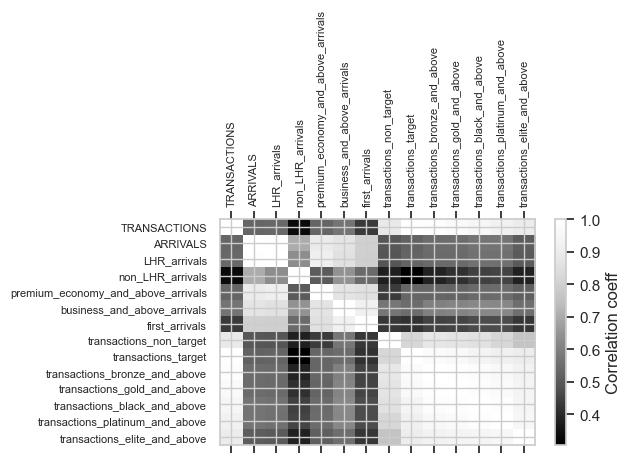

In [25]:
import matplotlib.pyplot as plt

# 1. Filter to only Middle East - GCC and compute correlations
df_gcc = merged_week_country[merged_week_country['COUNTRY'] == 'Middle East - GCC']
numeric_cols = df_gcc.select_dtypes(include='number').columns
corr_matrix = df_gcc[numeric_cols].corr()

# 2. Plot heatmap with strongest correlations as darkest cells
fig, ax = plt.subplots()
cax = ax.matshow(corr_matrix, aspect='auto', cmap='Greys_r')
fig.colorbar(cax, ax=ax, label='Correlation coeff')

# 3. Label axes
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols, fontsize=8)

plt.tight_layout()
plt.show()

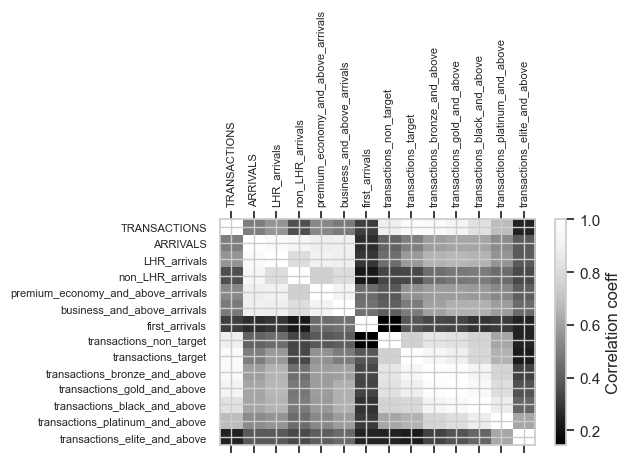

In [26]:
import matplotlib.pyplot as plt

# 1. Filter to only Middle East - GCC and compute correlations
df_gcc = merged_week_country[merged_week_country['COUNTRY'] == 'RO APAC']
numeric_cols = df_gcc.select_dtypes(include='number').columns
corr_matrix = df_gcc[numeric_cols].corr()

# 2. Plot heatmap with strongest correlations as darkest cells
fig, ax = plt.subplots()
cax = ax.matshow(corr_matrix, aspect='auto', cmap='Greys_r')
fig.colorbar(cax, ax=ax, label='Correlation coeff')

# 3. Label axes
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols, fontsize=8)

plt.tight_layout()
plt.show()

## Nonlinearity

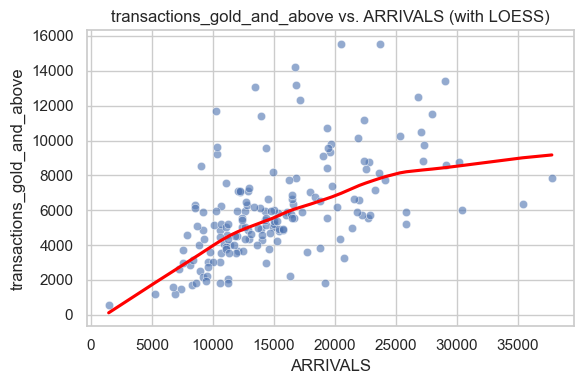

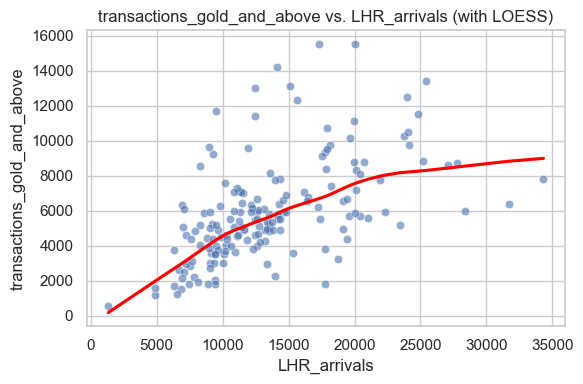

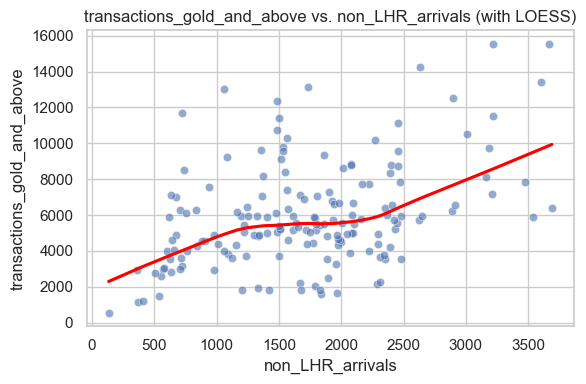

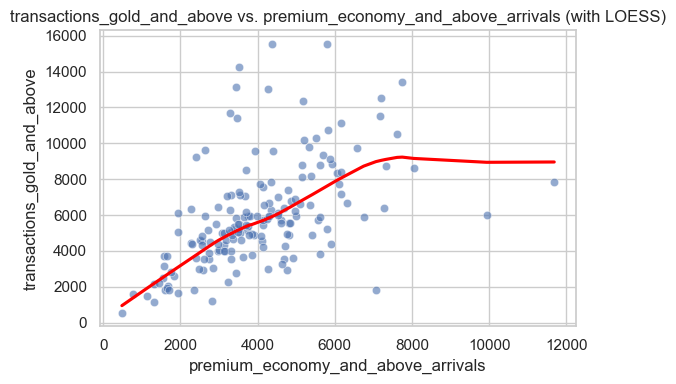

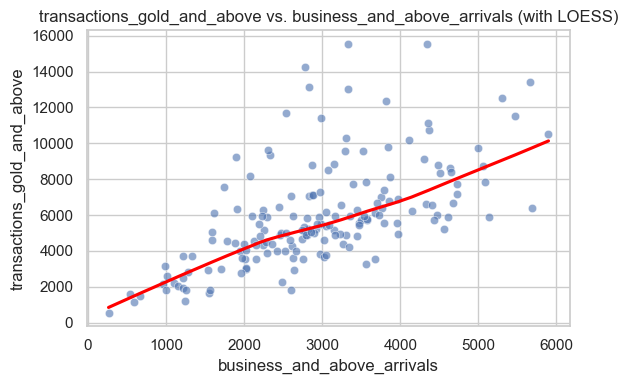

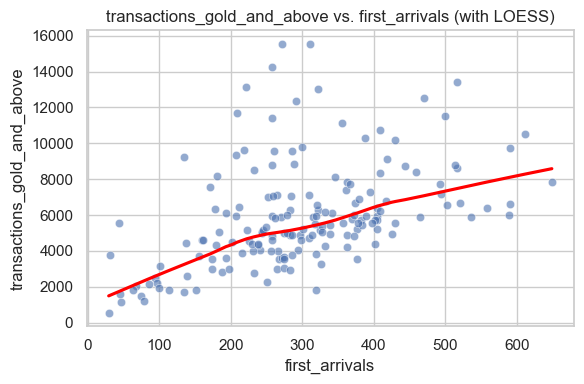

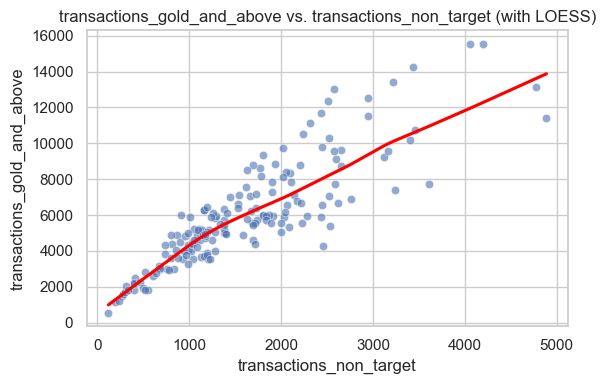

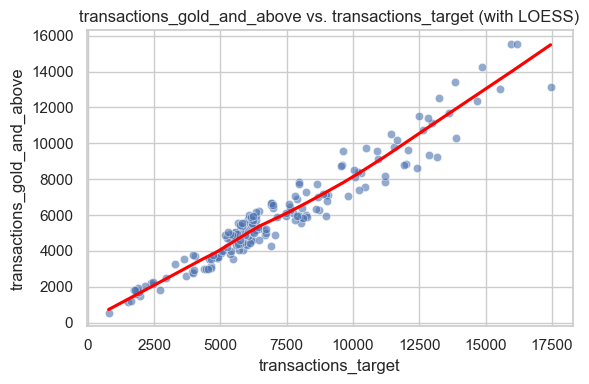

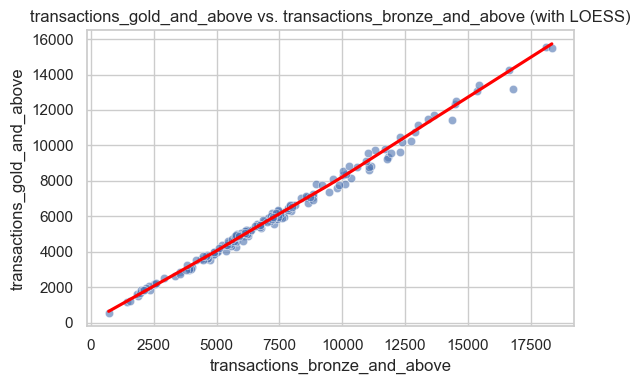

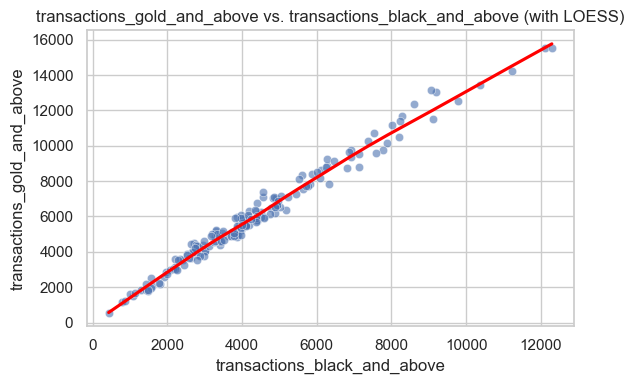

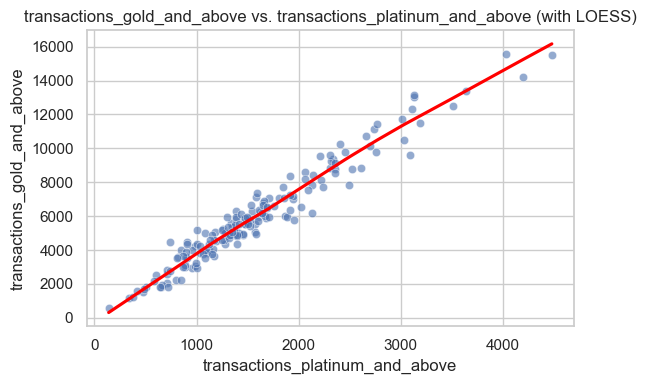

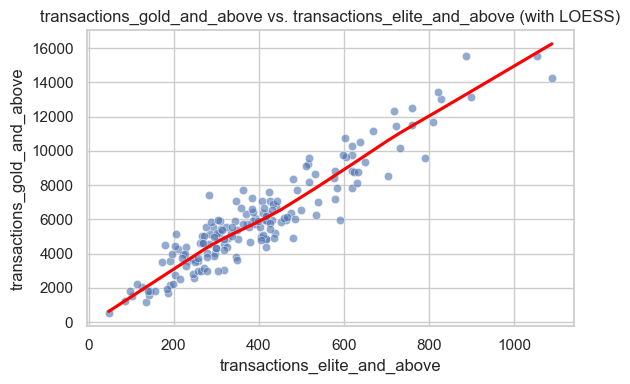

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# your dataframe
df = merged_week_country[merged_week_country['COUNTRY'] == 'Middle East - GCC'].copy()

# choose your provisional target
target = "transactions_gold_and_above"

# list all numeric predictors except DATE and target
predictors = [
    "ARRIVALS", "LHR_arrivals", "non_LHR_arrivals",
    "premium_economy_and_above_arrivals", "business_and_above_arrivals",
    "first_arrivals", "transactions_non_target", "transactions_target",
    "transactions_bronze_and_above", "transactions_black_and_above",
    "transactions_platinum_and_above", "transactions_elite_and_above"
]

# loop through predictors and plot scatter + LOESS
for col in predictors:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=col, y=target, data=df, alpha=0.6)
    sns.regplot(x=col, y=target, data=df, lowess=True,
                scatter=False, line_kws={"color": "red"})
    plt.title(f"{target} vs. {col} (with LOESS)")
    plt.tight_layout()
    plt.show()


In [18]:
# 1. sort and shift within each country
df = merged_week_country.sort_values(['COUNTRY','DATE']).copy()
predictors = [
    "ARRIVALS", "LHR_arrivals", 
    "business_and_above_arrivals"
]
for col in predictors:
    df[f"{col}_lag1"] = (
        df
        .groupby('COUNTRY')[col]
        .shift(1)
    )

# 2. drop the weeks that now have NaNs in any lagged column
df = df.dropna(subset=[f"{c}_lag1" for c in predictors])

# 3. redefine y and X (using only the lagged features)
y = df["transactions_gold_and_above"]
X = df[[f"{c}_lag1" for c in predictors]]

# 4. re‐run your CV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

lr = LinearRegression()
r2_lr = cross_val_score(lr, X, y, cv=5, scoring="r2").mean()

rf = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=0)
r2_rf = cross_val_score(rf, X, y, cv=5, scoring="r2").mean()

print(f"Linear R² (lagged CV): {r2_lr:.3f}")
print(f"RF R² (lagged CV):     {r2_rf:.3f}")
print(f"ΔR² = {r2_rf - r2_lr:.3f}")


Linear R² (lagged CV): 0.419
RF R² (lagged CV):     0.341
ΔR² = -0.077


In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

# 1) prep
df = merged_week_country.sort_values(['COUNTRY','DATE']).copy()

predictors = [
    "ARRIVALS",   "business_and_above_arrivals"
]

# 2) create lag-1 for each predictor
for col in predictors:
    df[f"{col}_lag1"] = df.groupby('COUNTRY')[col].shift(1)

# 3) drop rows with any NaN in the lagged cols
lag_cols = [f"{c}_lag1" for c in predictors]
df = df.dropna(subset=lag_cols)

# 4) define target & X
y = df["transactions_gold_and_above"].values
X = df[lag_cols].values

# 5) time-series CV
tscv = TimeSeriesSplit(n_splits=5)

# 6) eval
lr = LinearRegression()
r2_lr = cross_val_score(lr, X, y, cv=tscv, scoring="r2").mean()

rf = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=0)
r2_rf = cross_val_score(rf, X, y, cv=tscv, scoring="r2").mean()

print(f"Linear R² (lagged CV): {r2_lr:.3f}")
print(f"RF R²     (lagged CV): {r2_rf:.3f}")
print(f"ΔR² = {r2_rf - r2_lr:.3f}")


Linear R² (lagged CV): 0.307
RF R²     (lagged CV): 0.153
ΔR² = -0.154


## Modeling Insights & Recommendations

This analysis evaluated linear vs. non-linear and piecewise-linear approaches for predicting `transactions_gold_and_above` from arrival metrics.

---

### Key Qualitative Findings

- **Predominantly Linear Relationships**  
  Except for specific thresholds in total and non-LHR arrivals, the transaction metrics scale roughly proportionally with arrival volumes. A straightforward linear regression explains nearly all variance (R²≈0.996), outperforming a small Random Forest (R²≈0.980).

- **Regime Shifts in Select Metrics**  
  - **Total ARRIVALS**: below ~66k arrivals, each additional arrival yields a modest transaction lift; above this, conversion accelerates significantly.
  - **non_LHR_arrivals**: similar pattern with threshold around ~8k non-LHR; conversion per non-LHR arrival jumps past the knot.
  - **LHR_arrivals**: mild breakpoint at ~8.8k, suggesting a modest slope increase for Heathrow traffic.

- **Other Features**  
  Premium, business, first-class arrivals and existing transaction categories show no meaningful piecewise benefit. Their impact on `transactions_gold_and_above` remains constant across ranges.

---

### Modeling Recommendations

1. **Base Model**: use linear regression with regularization (Ridge or Lasso) to capture strong overall linear trends.  
2. **Hinge Terms**: introduce piecewise-linear (hinge) features for ARRIVALS and non_LHR_arrivals to model observed regime shifts. Optionally add for LHR_arrivals for additional nuance.  
3. **Validation**: confirm cross-validated performance lifts from hinge terms; expect ΔR² of ~0.12–0.15 for ARRIVALS and non_LHR_arrivals.  
4. **Parsimony**: avoid full tree-based models, as they add complexity without improving predictive power.

---

### Business Implications

- Below identified thresholds, incremental arrivals yield steady growth in high-value transactions.  
- Beyond thresholds, conversion efficiency increases—signal for scaling up marketing and operational capacity when volumes surpass these levels.


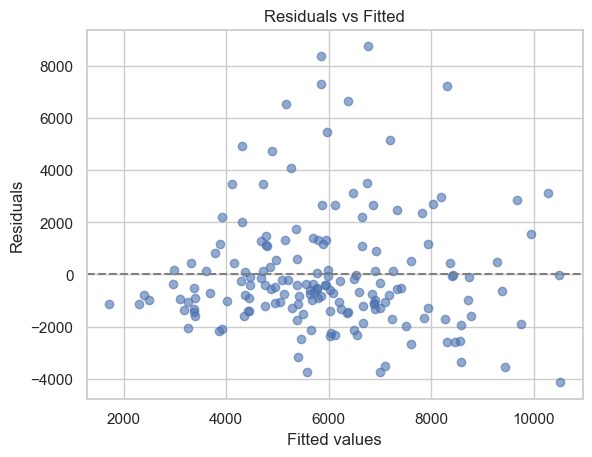

{'LM stat': np.float64(8.327169289945834), 'LM p-value': np.float64(0.039712563391009086), 'F-stat': np.float64(2.8500152562431467), 'F p-value': np.float64(0.039092328823134126)}


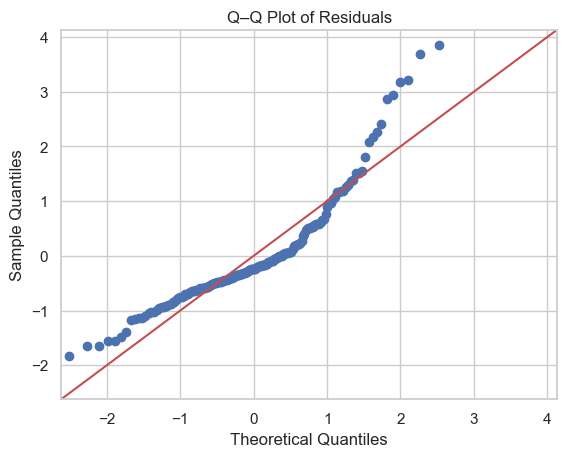

Shapiro–Wilk: ShapiroResult(statistic=np.float64(0.8797793033986419), pvalue=np.float64(1.8564065761956443e-10))
Durbin–Watson: 0.6087893803648504
                       feature         VIF
0                        const    8.451454
1                     ARRIVALS  116.203615
2  business_and_above_arrivals    4.078276
3                 LHR_arrivals  109.549739


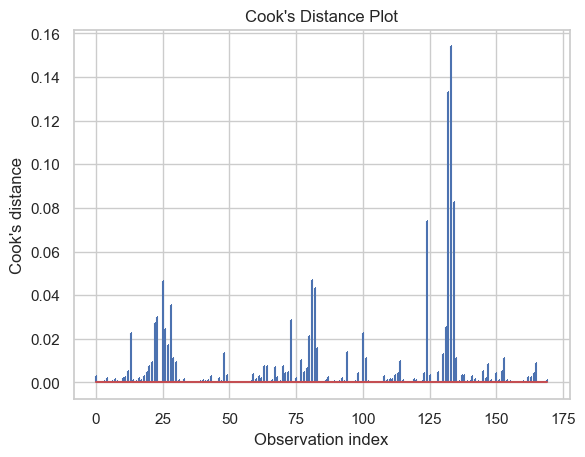

In [89]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from scipy import stats

# assume df = merged_country_weekly.copy()
y = df['transactions_gold_and_above']
X = df[['ARRIVALS', 'business_and_above_arrivals', 'LHR_arrivals', 
        # include any other linear predictors here
       ]]
X = sm.add_constant(X)

# fit OLS
model = sm.OLS(y, X).fit()
resid = model.resid
fitted = model.fittedvalues

# 1. Linearity & homoscedasticity: residuals vs fitted
plt.scatter(fitted, resid, alpha=0.6)
plt.axhline(0, color='grey', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# Breusch–Pagan test for heteroscedasticity
bp_test = het_breuschpagan(resid, model.model.exog)
labels = ['LM stat', 'LM p-value', 'F-stat', 'F p-value']
print(dict(zip(labels, bp_test)))

# 2. Normality of errors: Q–Q plot and Shapiro–Wilk
sm.qqplot(resid, line='45', fit=True)
plt.title('Q–Q Plot of Residuals')
plt.show()
print('Shapiro–Wilk:', stats.shapiro(resid))

# 3. Independence: Durbin–Watson
print('Durbin–Watson:', durbin_watson(resid))

# 4. Multicollinearity: VIF
vif_data = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_data)

# 5. Leverage & influence: Cook’s distance
influence = OLSInfluence(model)
cooks = influence.cooks_distance[0]
plt.stem(np.arange(len(cooks)), cooks, markerfmt=",")
plt.xlabel('Observation index')
plt.ylabel("Cook's distance")
plt.title("Cook's Distance Plot")
plt.show()


## Regression Assumptions

In [104]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import r2_score

# 1. Prepare data with a time-based train/test split
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

y_train = train_df['transactions_gold_and_above'].values
y_test  = test_df ['transactions_gold_and_above'].values

# 2. Define features
#    Drop perfectly collinear arrivals (keep only total ARRIVALS and non_LHR for variation)
X_train_lin = train_df[['business_and_above_arrivals', 'LHR_arrivals']].values
X_test_lin  = test_df [['business_and_above_arrivals', 'LHR_arrivals']].values

# 3. Add hinge (piecewise) features at the previously found knots
k_arr_total = 66290.2
k_arr_non   = 8083.8

def make_piecewise(X):
    arr, non_lhr = X[:,0], X[:,1]
    h1 = np.clip(arr - k_arr_total, 0, None)
    h2 = np.clip(non_lhr - k_arr_non,  0, None)
    return np.vstack([arr, non_lhr, h1, h2]).T

X_train_pw = make_piecewise(X_train_lin)
X_test_pw  = make_piecewise(X_test_lin)

# 4. Model definitions
lr = LinearRegression()
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)

models = {
    'OLS_linear':       (lr,       X_train_lin, X_test_lin),
    'Ridge_linear':     (ridge,    X_train_lin, X_test_lin),
    'Ridge_piecewise':  (ridge,    X_train_pw,  X_test_pw)
}

# 5. Train and evaluate
results = {}
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    results[name] = {
        'R2_in_sample':  r2_score(y_train, y_pred_tr),
        'R2_out_sample': r2_score(y_test,  y_pred_te)
    }

# 6. Display results
results_df = pd.DataFrame(results).T
print(results_df)


                 R2_in_sample  R2_out_sample
OLS_linear           0.586597      -0.212181
Ridge_linear         0.586597      -0.212181
Ridge_piecewise      0.603551      -0.264760


In [86]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# 1. Load & sort

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

# 2. Define X & y
X = df[['ARRIVALS']].values
y = df['TRANSACTIONS'].values

# 3. Fit OLS and compute in-sample R²
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r2_insample = r2_score(y, y_pred)

# 4. Compute squared Pearson correlation
r, _ = pearsonr(df['ARRIVALS'], df['transactions_gold_and_above'])
r2_pearson = r**2

print(f"In-sample OLS R²:       {r2_insample:.3f}")
print(f"Pearson’s r² (corr²):   {r2_pearson:.3f}")


In-sample OLS R²:       0.286
Pearson’s r² (corr²):   0.302


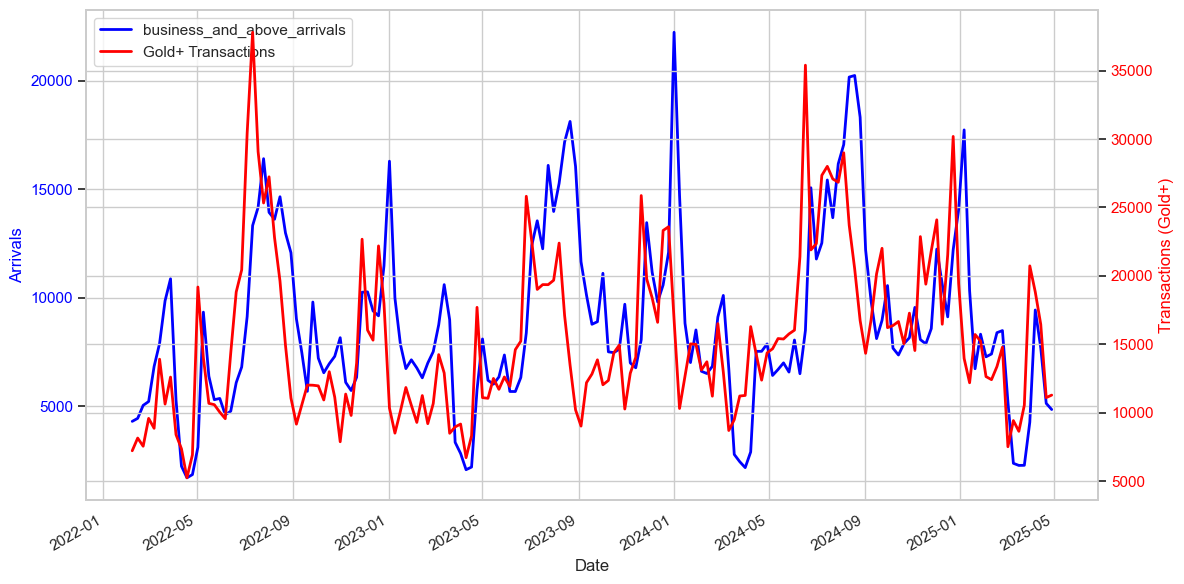

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

# prepare data
#df = merged_week_country.copy()
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

# create figure and first axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# plot arrivals on ax1 with explicit color
ax1.plot(df['DATE'], df['TRANSACTIONS'], color='blue', label='business_and_above_arrivals', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Arrivals', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# create second axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(df['DATE'], df['ARRIVALS'], color='red', label='Gold+ Transactions', linewidth=2)
ax2.set_ylabel('Transactions (Gold+)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# format
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


In [116]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

# prepare data
#df = merged_week_country.copy()
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

# features & target (example: lagged-arrivals + piecewise)
df['ARR_lag1'] = df['ARRIVALS'].shift(1)
df['h_arr']   = np.clip(df['ARR_lag1'] - 66290.2, 0, None)
df = df.dropna(subset=['ARR_lag1'])

X_lin = df[['ARR_lag1']].values
X_pw  = df[['ARR_lag1', 'h_arr']].values
y     = df['transactions_gold_and_above'].values

# define models
models = {
    'OLS':       LinearRegression(),
    'Ridge':     RidgeCV(alphas=[0.1,1,10], cv=3),
    'Ridge_PW':  RidgeCV(alphas=[0.1,1,10], cv=3)
}

# rolling-origin CV
tscv = TimeSeriesSplit(n_splits=5)
scores = {name: [] for name in models}

for train_idx, test_idx in tscv.split(X_lin):
    y_tr, y_te       = y[train_idx], y[test_idx]
    Xtr_lin, Xte_lin = X_lin[train_idx], X_lin[test_idx]
    Xtr_pw,  Xte_pw  = X_pw[train_idx],  X_pw[test_idx]
    
    # fit & score
    for name, model in models.items():
        Xtr = Xtr_lin  if name!='Ridge_PW' else Xtr_pw
        Xte = Xte_lin  if name!='Ridge_PW' else Xte_pw
        
        model.fit(Xtr, y_tr)
        y_pred = model.predict(Xte)
        scores[name].append(r2_score(y_te, y_pred))

# summarize
for name, sc in scores.items():
    print(f"{name} rolling-origin CV R²: mean {np.mean(sc):.3f}, splits {sc}")


OLS rolling-origin CV R²: mean 0.203, splits [-0.6143191099974883, 0.22956918406965254, 0.4939368272228827, 0.4773685105669797, 0.42966801043374536]
Ridge rolling-origin CV R²: mean 0.203, splits [-0.6143191099187499, 0.22956918405831406, 0.4939368266179486, 0.4773685092712172, 0.4296680109197326]
Ridge_PW rolling-origin CV R²: mean 0.203, splits [-0.6143191099187497, 0.22956918405831406, 0.4939368266179488, 0.4773685092712172, 0.4296680109197324]


In [110]:
# identify all “arrivals” columns
arr_cols = [col for col in df.columns if 'arrivals' in col.lower()]

# sort by country and date so shift is meaningful
df = df.sort_values(['COUNTRY', 'DATE'])

# shift each arrivals column down by one week within each country
df[arr_cols] = df.groupby('COUNTRY')[arr_cols].shift(2)

# drop the first-week rows (they’ll have NaN in the shifted arrivals)
df = df.dropna(subset=arr_cols).reset_index(drop=True)


In [77]:
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score

# 1. Prepare & align
df = merged_week_country.copy()
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

# Feature: next-week arrivals (known from bookings)
df['ARRIVALS_lead1'] = df['ARRIVALS'].shift(-1)

# Target: this-week transactions
df['trans_now'] = df['transactions_gold_and_above']

# Drop rows where arrivals_lead1 is NaN (i.e. last week)
df = df.dropna(subset=['ARRIVALS_lead1'])

# 2. Time-based split
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

X_train = train[['ARRIVALS_lead1']]
X_test  = test [['ARRIVALS_lead1']]
y_train = train['trans_now']
y_test  = test ['trans_now']

# 3. Fit & evaluate
model = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5).fit(X_train, y_train)
print("In-sample R² :", r2_score(y_train, model.predict(X_train)))
print("Out-sample R²:", r2_score(y_test,  model.predict(X_test)))


In-sample R² : 0.1260370190917499
Out-sample R²: -0.002133248492447226


In [118]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

# 1. Prepare & align data
df = merged_week_country.copy()
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

# create lagged features
df['ARR_lag1']   = df['ARRIVALS'].shift(1)
df['trans_lag1'] = df['transactions_gold_and_above'].shift(1)
# piecewise hinge on lagged arrivals
k_arr = 66290.2
df['h_arr']      = np.clip(df['ARR_lag1'] - k_arr, 0, None)

# drop rows with NaNs
df = df.dropna(subset=['ARR_lag1', 'trans_lag1'])

# define X and y
X = df[['ARR_lag1', 'h_arr', 'trans_lag1']].values
y = df['transactions_gold_and_above'].values

# 2. Rolling-origin CV
tscv = TimeSeriesSplit(n_splits=5)
models = {
    'OLS':      LinearRegression(),
    'Ridge':    RidgeCV(alphas=[0.1,1,10], cv=3)
}

scores = {name: [] for name in models}

for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    for name, m in models.items():
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        scores[name].append(r2_score(y_te, y_pred))

# 3. Results
for name, sc in scores.items():
    print(f"{name} rolling-origin CV R²: mean {np.mean(sc):.3f}, splits {sc}")


OLS rolling-origin CV R²: mean 0.728, splits [0.5599129126459297, 0.8224096419240509, 0.6617580490982131, 0.9061430001774519, 0.6913960597759581]
Ridge rolling-origin CV R²: mean 0.728, splits [0.5599129125077605, 0.8224096417693989, 0.6617580491513602, 0.906143000173605, 0.6913960597865718]


In [122]:
import pandas as pd
from datetime import timedelta

# --- 1. start with your weekly df ------------------------------------------------
df = merged_week_country.copy()
df['DATE'] = pd.to_datetime(df['DATE'])          # weekly period start (e.g., Monday)
df = df.sort_values('DATE')

# --- 2. SEASON column (meteorological seasons) -----------------------------------
def season_from_month(m):
    return {12:'Winter', 1:'Winter', 2:'Winter',
            3:'Spring', 4:'Spring', 5:'Spring',
            6:'Summer', 7:'Summer', 8:'Summer',
            9:'Autumn',10:'Autumn',11:'Autumn'}[m]

df['SEASON'] = df['DATE'].dt.month.map(season_from_month)

# --- 3. HOLIDAY column – 1 if ANY Middle-East Islamic holiday falls in that week -
# helper to build inclusive date ranges
def drange(start, end):
    return pd.date_range(start, end, freq='D')

holiday_dates = pd.to_datetime([
    # Ramadan - Eid periods 2022-2025 (inclusive)
    *drange('2022-04-02', '2022-05-01'),           # Ramadan 2022
    *drange('2022-05-02', '2022-05-04'),           # Eid al-Fitr 2022
    *drange('2022-07-09', '2022-07-12'),           # Eid al-Adha 2022
    '2022-07-30',                                  # Islamic New Year 1444
    '2022-10-08',                                  # Mawlid 2022

    *drange('2023-03-22', '2023-04-20'),           # Ramadan 2023
    *drange('2023-04-21', '2023-04-23'),           # Eid al-Fitr 2023
    *drange('2023-06-28', '2023-07-01'),           # Eid al-Adha 2023
    '2023-07-19',                                  # Islamic New Year 1445
    '2023-09-27',                                  # Mawlid 2023

    *drange('2024-03-10', '2024-04-08'),           # Ramadan 2024
    *drange('2024-04-10', '2024-04-12'),           # Eid al-Fitr 2024
    *drange('2024-06-16', '2024-06-19'),           # Eid al-Adha 2024
    '2024-07-07',                                  # Islamic New Year 1446
    '2024-09-15',                                  # Mawlid 2024

    *drange('2025-02-28', '2025-03-29'),           # Ramadan 2025 (data ≤ Apr 2025)
    *drange('2025-03-31', '2025-04-02')            # Eid al-Fitr 2025
])

# convert each holiday date to its week-start (Monday) and build a set
holiday_week_starts = {
    (d - timedelta(days=d.weekday())).normalize() for d in holiday_dates
}

# mark weeks: 1 if any holiday falls within that Monday-Sunday window
df['HOLIDAY'] = df['DATE'].isin(holiday_week_starts).astype(int)

# --- done ------------------------------------------------------------------------
# df now has binary SEASON (categorical) and HOLIDAY (0/1) columns


In [130]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
# Recompute ARR_lag1 as the one-week lag of ARRIVALS
df = df.copy()
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

# Define ARR_lag1: previous week’s total arrivals
df['ARR_lag1'] = df['ARRIVALS'].shift(1)
df['trans_lag1'] = df['TRANSACTIONS'].shift(1)

# Drop the first row (where ARR_lag1 is NaN) before modeling
df = df.dropna(subset=['ARR_lag1'])

# ------------------------------------------------------------------
# 1. Utility: rolling-origin R² for any feature list
# ------------------------------------------------------------------
def rolling_r2(df, feature_cols, target, n_splits=5):
    """Time-series CV R² (expanding window)."""
    X = df[feature_cols].values
    y = df[target].values
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = [
        r2_score(y[test], LinearRegression().fit(X[train], y[train]).predict(X[test]))
        for train, test in tscv.split(X)
    ]
    return np.mean(scores)

# ------------------------------------------------------------------
# 2. Prep data  (assumes ARR_lag1, trans_lag1, SEASON, HOLIDAY already exist)
# ------------------------------------------------------------------
#Edf = df.copy().sort_values('DATE')
df = df.dropna(subset=['ARR_lag1', 'trans_lag1'])        # drop first row(s)

# one-hot the SEASON column
df = pd.get_dummies(df, columns=['SEASON'], drop_first=True)

# feature groups
base      = ['ARR_lag1', 'trans_lag1']
season    = [c for c in df.columns if c.startswith('SEASON_')]
holiday   = ['HOLIDAY']
target    = 'transactions_gold_and_above'

# ------------------------------------------------------------------
# 3. Evaluate incremental contributions
# ------------------------------------------------------------------
r2_base   = rolling_r2(df, base,                    target)
r2_season = rolling_r2(df, base + season,          target)
r2_hol    = rolling_r2(df, base + holiday,         target)
r2_full   = rolling_r2(df, base + season + holiday,target)

print(f"Base (ARR_lag1 + trans_lag1) R²:   {r2_base:.3f}")
print(f"+ SEASON dummies R²:               {r2_season:.3f}  (Δ = {r2_season - r2_base:+.3f})")
print(f"+ HOLIDAY flag R²:                 {r2_hol:.3f}     (Δ = {r2_hol   - r2_base:+.3f})")
print(f"+ BOTH (full model) R²:            {r2_full:.3f}    (Δ = {r2_full  - r2_base:+.3f})")


Base (ARR_lag1 + trans_lag1) R²:   0.658
+ SEASON dummies R²:               0.647  (Δ = -0.011)
+ HOLIDAY flag R²:                 0.672     (Δ = +0.015)
+ BOTH (full model) R²:            0.656    (Δ = -0.002)
